# ZED SDK Custom 标定展示帧

本 Notebook 从 `20260802_150233.svo2` 中抽取一帧，使用 `Calibration/zed_custom_opencv.yml` 打开 ZED SDK，展示：

- ZED SDK `VIEW.LEFT` 左目图像；
- ZED SDK `VIEW.RIGHT` 右目图像；
- ZED SDK `MEASURE.DEPTH` 深度图。

左右图像和深度图来自同一个 SVO 帧。深度图使用 SDK 的 NEURAL 深度引擎，单位为米；伪彩色中蓝色表示近处，红色表示远处。

In [1]:
from pathlib import Path
import json
import os

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        required = [
            candidate / '20260802_150233.svo2',
            candidate / 'Calibration' / 'zed_custom_opencv.yml',
        ]
        if all(path.is_file() for path in required):
            return candidate
    raise FileNotFoundError('Cannot locate the BinocularCamera project root')

PROJECT_ROOT = find_project_root()
SVO_PATH = PROJECT_ROOT / '20260802_150233.svo2'
CALIBRATION_PATH = PROJECT_ROOT / 'Calibration' / 'zed_custom_opencv.yml'
ASSET_DIR = PROJECT_ROOT / 'notebook_assets'
ASSET_DIR.mkdir(parents=True, exist_ok=True)

# 可改成任意有效的 SVO 帧号。1000 通常适合作为展示帧。
FRAME_INDEX = 1000
CENTER_WINDOW_RADIUS = 15
DEPTH_VALID_MAX_M = 50.0
DEPTH_DISPLAY_PERCENTILES = (2.0, 98.0)

print(f'Project root: {PROJECT_ROOT}')
print(f'SVO: {SVO_PATH.name}')
print(f'Calibration: {CALIBRATION_PATH.relative_to(PROJECT_ROOT)}')
print(f'Requested frame: {FRAME_INDEX}')

Project root: D:\Underwater\BinocularCamera
SVO: 20260802_150233.svo2
Calibration: Calibration\zed_custom_opencv.yml
Requested frame: 1000


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ZED SDK 的 DLL 必须在导入 pyzed.sl 前加入搜索路径。
sdk_root = Path(os.environ.get('ZED_SDK_ROOT_DIR', 'C:/Program Files (x86)/ZED SDK.old'))
if os.name == 'nt':
    sdk_dirs = [
        sdk_root / 'bin',
        sdk_root / 'dependencies' / 'freeglut' / 'bin',
        sdk_root / 'dependencies' / 'freeglut_2.8' / 'x64',
        sdk_root / 'dependencies' / 'glew' / 'bin',
        sdk_root / 'dependencies' / 'glew-1.12.0' / 'x64',
        sdk_root / 'dependencies' / 'opencv' / 'x64' / 'vc16' / 'bin',
        sdk_root / 'dependencies' / 'opencv_3.1.0' / 'x64',
    ]
    sdk_dirs = [path for path in sdk_dirs if path.is_dir()]
    if not sdk_dirs:
        raise FileNotFoundError(f'No ZED SDK DLL directories found under {sdk_root}')
    current_path = [item for item in os.environ.get('PATH', '').split(os.pathsep) if item]
    os.environ['PATH'] = os.pathsep.join([*(str(path) for path in sdk_dirs), *current_path])
    if hasattr(os, 'add_dll_directory'):
        _zed_dll_handles = [os.add_dll_directory(str(path)) for path in sdk_dirs]

import pyzed.sl as sl

print(f'ZED SDK: {sl.Camera.get_sdk_version()}')
print(f'Python: {os.sys.executable}')

ZED SDK: 5.4.1
Python: C:\Users\10179\.conda\envs\zed\python.exe


In [3]:
def read_custom_calibration(path):
    storage = cv2.FileStorage(str(path), cv2.FILE_STORAGE_READ)
    if not storage.isOpened():
        raise RuntimeError(f'Cannot open calibration file: {path}')
    try:
        size_node = storage.getNode('Size')
        width = int(round(size_node.at(0).real()))
        height = int(round(size_node.at(1).real()))

        def matrix(name):
            value = storage.getNode(name).mat()
            if value is None:
                raise RuntimeError(f'Missing {name} in {path}')
            return np.asarray(value, dtype=np.float64)

        result = {
            'width': width,
            'height': height,
            'K_LEFT': matrix('K_LEFT'),
            'K_RIGHT': matrix('K_RIGHT'),
            'D_LEFT': matrix('D_LEFT').reshape(-1),
            'D_RIGHT': matrix('D_RIGHT').reshape(-1),
            'R': matrix('R').reshape(-1),
            'T_mm': matrix('T').reshape(-1),
        }
    finally:
        storage.release()
    return result

calibration = read_custom_calibration(CALIBRATION_PATH)
calibration_summary = {
    'image_size': [calibration['width'], calibration['height']],
    'left_fx_fy_cx_cy': [
        float(calibration['K_LEFT'][0, 0]),
        float(calibration['K_LEFT'][1, 1]),
        float(calibration['K_LEFT'][0, 2]),
        float(calibration['K_LEFT'][1, 2]),
    ],
    'right_fx_fy_cx_cy': [
        float(calibration['K_RIGHT'][0, 0]),
        float(calibration['K_RIGHT'][1, 1]),
        float(calibration['K_RIGHT'][0, 2]),
        float(calibration['K_RIGHT'][1, 2]),
    ],
    'baseline_norm_mm': float(np.linalg.norm(calibration['T_mm'])),
}
print(json.dumps(calibration_summary, ensure_ascii=False, indent=2))

{
  "image_size": [
    1920,
    1080
  ],
  "left_fx_fy_cx_cy": [
    1443.326338,
    1441.541002,
    967.033878,
    540.469238
  ],
  "right_fx_fy_cx_cy": [
    1449.830254,
    1448.097563,
    975.331674,
    514.232843
  ],
  "baseline_norm_mm": 123.7302227994842
}


In [4]:
def check_status(status, operation):
    if status > sl.ERROR_CODE.SUCCESS:
        raise RuntimeError(f'{operation} failed: {status}')

def as_rgb(image):
    image = np.asarray(image)
    if image.ndim == 3 and image.shape[2] == 4:
        return cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
    if image.ndim == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    raise RuntimeError(f'Unexpected image shape: {image.shape}')

init = sl.InitParameters()
init.set_from_svo_file(str(SVO_PATH))
init.svo_real_time_mode = False
init.depth_mode = sl.DEPTH_MODE.NEURAL
init.coordinate_units = sl.UNIT.METER
init.coordinate_system = sl.COORDINATE_SYSTEM.RIGHT_HANDED_Y_UP
init.camera_disable_self_calib = True
init.optional_opencv_calibration_file = str(CALIBRATION_PATH)
init.depth_stabilization = 0
init.enable_image_enhancement = False

zed = sl.Camera()
check_status(zed.open(init), 'open SVO with Custom calibration')
info = zed.get_camera_information()
total_frames = int(zed.get_svo_number_of_frames())
if not 0 <= FRAME_INDEX < total_frames:
    zed.close()
    raise ValueError(f'FRAME_INDEX must be in [0, {total_frames - 1}]')

check_status(zed.set_svo_position(FRAME_INDEX), 'seek to requested SVO frame')
runtime = sl.RuntimeParameters()
runtime.confidence_threshold = 30
runtime.texture_confidence_threshold = 100
runtime.measure3D_reference_frame = sl.REFERENCE_FRAME.CAMERA
check_status(zed.grab(runtime), 'grab requested SVO frame')
actual_frame = int(zed.get_svo_position())

left_mat = sl.Mat()
right_mat = sl.Mat()
depth_mat = sl.Mat()
check_status(zed.retrieve_image(left_mat, sl.VIEW.LEFT), 'retrieve left image')
check_status(zed.retrieve_image(right_mat, sl.VIEW.RIGHT), 'retrieve right image')
check_status(zed.retrieve_measure(depth_mat, sl.MEASURE.DEPTH), 'retrieve SDK depth')

left_rgb = as_rgb(np.array(left_mat.get_data(), copy=True))
right_rgb = as_rgb(np.array(right_mat.get_data(), copy=True))
depth = np.array(depth_mat.get_data(), copy=True)
if depth.ndim == 3:
    depth = depth[..., 0]
depth = depth.astype(np.float32, copy=False)

print(f'SDK total frames: {total_frames}')
print(f'Requested / actual frame: {FRAME_INDEX} / {actual_frame}')
print(f'Left / right / depth shapes: {left_rgb.shape} / {right_rgb.shape} / {depth.shape}')

SDK total frames: 35855
Requested / actual frame: 1000 / 1000
Left / right / depth shapes: (1080, 1920, 3) / (1080, 1920, 3) / (1080, 1920)


In [5]:
# 运行时核对：SDK 实际读取的 raw 内参与 Custom YAML 一致。
raw = info.camera_configuration.calibration_parameters_raw

def camera_values(camera):
    return {
        'fx_px': float(camera.fx),
        'fy_px': float(camera.fy),
        'cx_px': float(camera.cx),
        'cy_px': float(camera.cy),
    }

sdk_left = camera_values(raw.left_cam)
sdk_right = camera_values(raw.right_cam)
expected_rotation = cv2.Rodrigues(calibration['R'].reshape(3, 1))[0]
expected_t_m = calibration['T_mm'] / 1000.0
expected_transform = np.eye(4, dtype=np.float64)
expected_transform[:3, :3] = expected_rotation.T
expected_transform[:3, 3] = -expected_rotation.T @ expected_t_m
observed_transform = np.asarray(raw.stereo_transform.m, dtype=np.float64).reshape(4, 4)

runtime_errors = {
    'left_fx_px': abs(sdk_left['fx_px'] - calibration['K_LEFT'][0, 0]),
    'left_fy_px': abs(sdk_left['fy_px'] - calibration['K_LEFT'][1, 1]),
    'left_cx_px': abs(sdk_left['cx_px'] - calibration['K_LEFT'][0, 2]),
    'left_cy_px': abs(sdk_left['cy_px'] - calibration['K_LEFT'][1, 2]),
    'right_fx_px': abs(sdk_right['fx_px'] - calibration['K_RIGHT'][0, 0]),
    'right_fy_px': abs(sdk_right['fy_px'] - calibration['K_RIGHT'][1, 1]),
    'right_cx_px': abs(sdk_right['cx_px'] - calibration['K_RIGHT'][0, 2]),
    'right_cy_px': abs(sdk_right['cy_px'] - calibration['K_RIGHT'][1, 2]),
    'stereo_transform_max_abs': float(np.max(np.abs(observed_transform - expected_transform))),
}
runtime_check = {
    'passed': max(runtime_errors.values()) <= 2e-3,
    'sdk_raw_left': sdk_left,
    'sdk_raw_right': sdk_right,
    'baseline_norm_m': float(np.linalg.norm(observed_transform[:3, 3])),
    'max_abs_errors': runtime_errors,
}
if not runtime_check['passed']:
    raise RuntimeError(runtime_check)
print(json.dumps(runtime_check, ensure_ascii=False, indent=2))

{
  "passed": true,
  "sdk_raw_left": {
    "fx_px": 1443.3262939453125,
    "fy_px": 1441.541015625,
    "cx_px": 967.0338745117188,
    "cy_px": 540.46923828125
  },
  "sdk_raw_right": {
    "fx_px": 1449.8302001953125,
    "fy_px": 1448.0975341796875,
    "cx_px": 975.3316650390625,
    "cy_px": 514.2328491210938
  },
  "baseline_norm_m": 0.12373023519059831,
  "max_abs_errors": {
    "left_fx_px": 4.405468757795461e-05,
    "left_fy_px": 1.3625000065076165e-05,
    "left_cx_px": 3.488281208774424e-06,
    "left_cy_px": 2.812499815263436e-07,
    "right_fx_px": 5.38046874680731e-05,
    "right_fy_px": 2.882031253648165e-05,
    "right_cx_px": 8.96093752089655e-06,
    "right_cy_px": 6.121093747424311e-06,
    "stereo_transform_max_abs": 0.0007127036403138803
  }
}


Valid depth ratio: 93.60%
Display range (2%–98%): 1.905 .. 2.159 m
Center pixel depth: 2.045 m
Center 31x31 median depth: 2.045 m


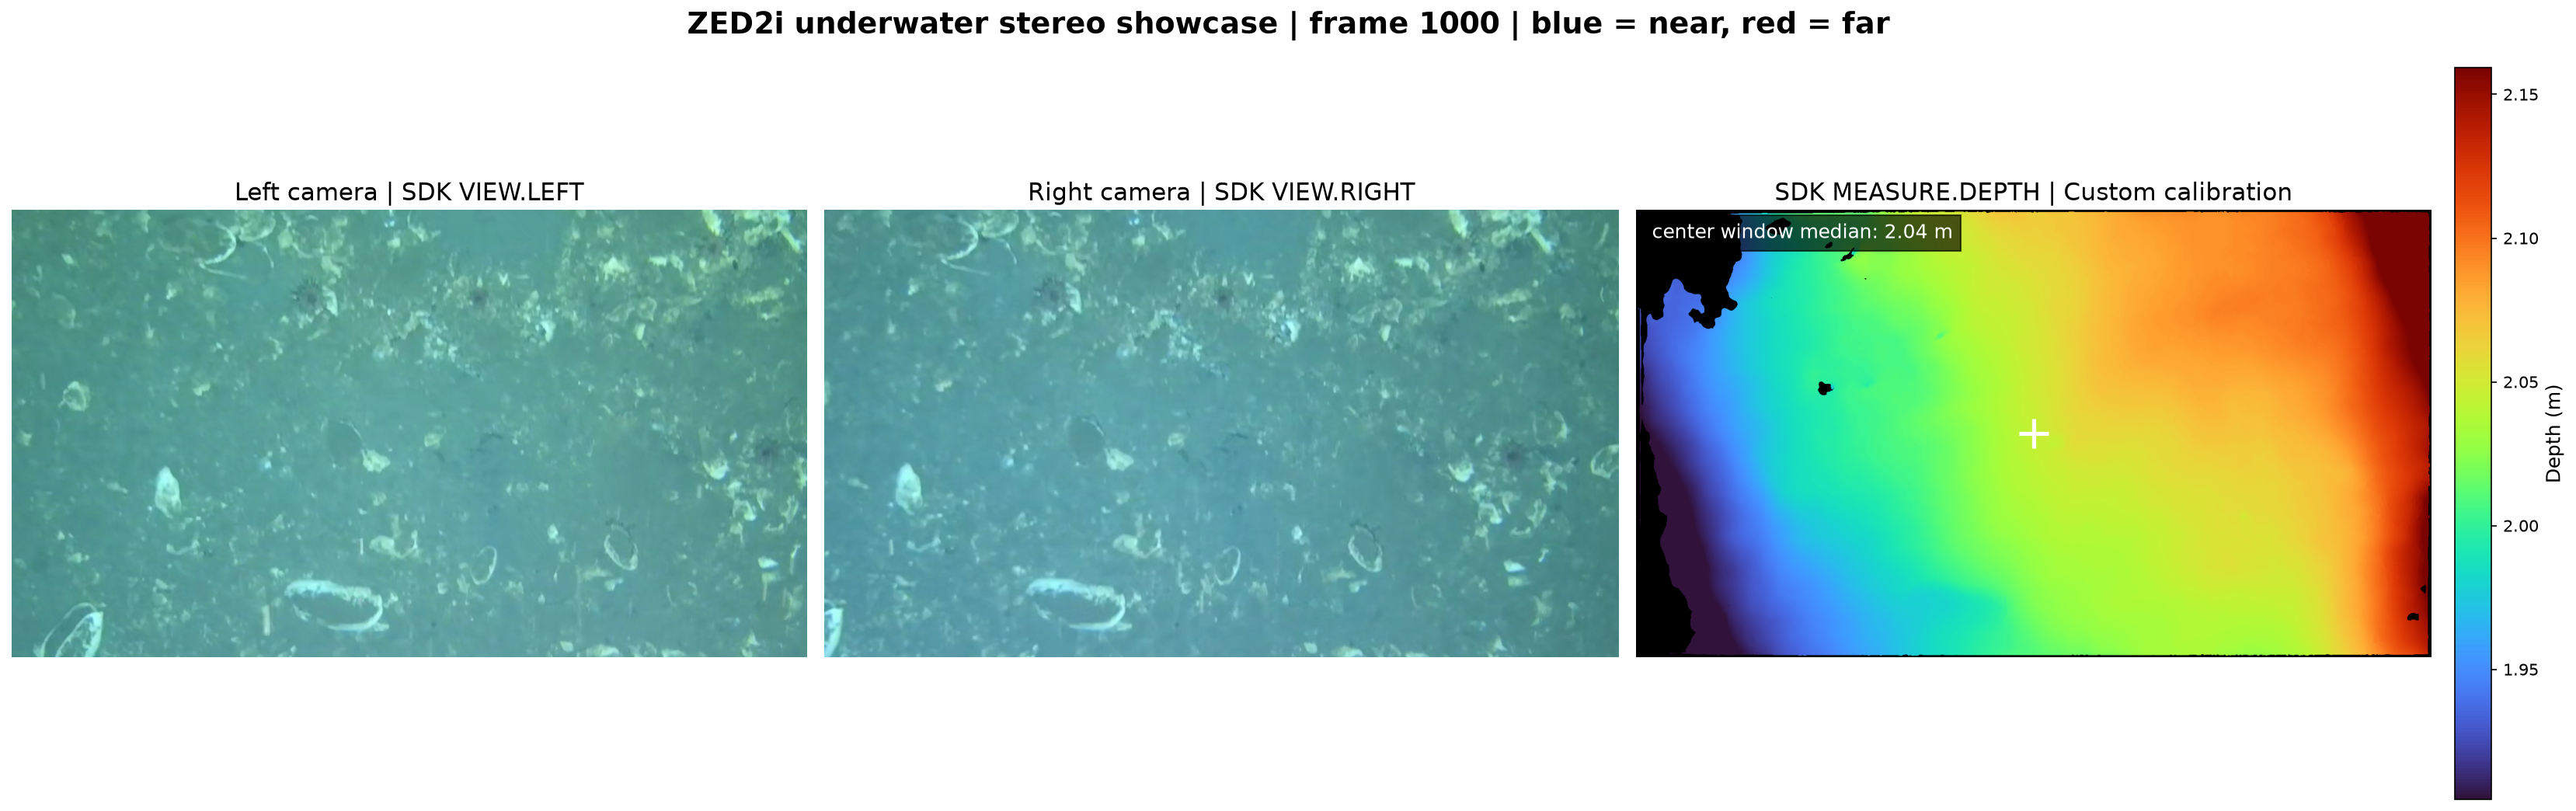

In [6]:
height, width = depth.shape
cx, cy = width // 2, height // 2
r = CENTER_WINDOW_RADIUS
center_window = depth[max(0, cy - r):min(height, cy + r + 1), max(0, cx - r):min(width, cx + r + 1)]
valid = np.isfinite(depth) & (depth > 0.0) & (depth <= DEPTH_VALID_MAX_M)
valid_values = depth[valid]
if valid_values.size == 0:
    raise RuntimeError('SDK returned no valid depth values in the selected frame')
display_low, display_high = np.percentile(valid_values, DEPTH_DISPLAY_PERCENTILES)
if display_high <= display_low:
    display_high = display_low + 1.0
center_valid = center_window[np.isfinite(center_window) & (center_window > 0.0) & (center_window <= DEPTH_VALID_MAX_M)]
center_pixel_depth = float(depth[cy, cx]) if np.isfinite(depth[cy, cx]) else float('nan')
center_median_depth = float(np.median(center_valid)) if center_valid.size else float('nan')

masked_depth = np.ma.masked_where(~valid, depth)
cmap = plt.get_cmap('turbo').copy()
cmap.set_bad(color='black')
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150, constrained_layout=True)
axes[0].imshow(left_rgb)
axes[0].set_title('Left camera | SDK VIEW.LEFT', fontsize=15)
axes[1].imshow(right_rgb)
axes[1].set_title('Right camera | SDK VIEW.RIGHT', fontsize=15)
depth_artist = axes[2].imshow(masked_depth, cmap=cmap, vmin=display_low, vmax=display_high)
axes[2].plot(cx, cy, marker='+', markersize=18, markeredgewidth=2.5, color='white')
axes[2].set_title('SDK MEASURE.DEPTH | Custom calibration', fontsize=15)
axes[2].text(0.02, 0.97, f'center window median: {center_median_depth:.2f} m', transform=axes[2].transAxes, va='top', color='white', fontsize=12, bbox=dict(facecolor='black', alpha=0.65, pad=5))
for axis in axes:
    axis.axis('off')
colorbar = fig.colorbar(depth_artist, ax=axes[2], fraction=0.046, pad=0.03)
colorbar.set_label('Depth (m)', fontsize=12)
fig.suptitle(f'ZED2i underwater stereo showcase | frame {actual_frame} | blue = near, red = far', fontsize=18, fontweight='bold')

print(f'Valid depth ratio: {valid.mean():.2%}')
print(f'Display range ({DEPTH_DISPLAY_PERCENTILES[0]:.0f}%–{DEPTH_DISPLAY_PERCENTILES[1]:.0f}%): {display_low:.3f} .. {display_high:.3f} m')
print(f'Center pixel depth: {center_pixel_depth:.3f} m')
print(f'Center {2 * r + 1}x{2 * r + 1} median depth: {center_median_depth:.3f} m')
plt.show()

In [7]:
# 保存一张可直接放入报告或演示文稿的高清拼图。
SHOWCASE_PATH = ASSET_DIR / f'zed_sdk_custom_depth_frame_{actual_frame:06d}.png'
fig.savefig(SHOWCASE_PATH, dpi=220, bbox_inches='tight', facecolor='white')
print(f'Saved: {SHOWCASE_PATH}')

Saved: D:\Underwater\BinocularCamera\notebook_assets\zed_sdk_custom_depth_frame_001000.png


In [8]:
zed.close()
print('ZED camera closed.')

ZED camera closed.
